In [1]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [2]:

# LIBRARIES 
import xgboost as xgb 
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# SYNTHETIC DATA GENERATION 

# features: age, BMI, menstrual irregularity, testosterone level, 
# features cont: antral follicle count, race (black, white, hispanic, asian, pacific islander, native)

# VAN NOTE: 
def generate_pcos_data(start_df, num_records=500):
    np.random.seed(42)

    # race as a factor for diagnosis 
    races = ['Black', 'White', 'Hispanic', 'Asian', 'NHPI', 'AIAN']
    race = np.random.choice(races, num_records) 

    bmi = np.zeros(num_records) # empty bmp array 

    for i in range(num_records):
        if race[i] == 'Black':
            bmi[i] = np.random.normal(34, 6)   # bmi = 34 
        elif race[i] == 'Hispanic':
            bmi[i] = np.random.normal(31, 5) # bmi = 31, std = 5
        else:
            bmi[i] = np.random.normal(28, 5) 

    # realistic bmi bounds from 18-55
    bmi = np.clip(bmi, 18, 55).round(1) 

    # INDEPENDENT FEATURES 
    age = np.random.randint(18, 45, num_records)
    mi = np.random.randint(0, 2, num_records) 
    testosterone = np.round(np.random.uniform(15, 120, num_records), 1)
    afc = np.random.randint(2, 30, num_records) 


    # DIAGNOSIS BIAS 
    # high bmi, high t, mi increase PCOS probability 
    logit = (0.1 * bmi) + (0.05 * testosterone) + (2.0 * mi) + (0.1 * afc) - 9

    # simulate healthcare disparities in racial lens 
    # symptoms must be higher to overcome the penalty 
    conditions = [
        (race == 'Black'),
        (race == 'Hispanic')
    ]
    choices = [logit - 1.2, logit - 0.8]
    logit = np.select(conditions, choices, default=logit)

    
    # CONVERT BIAS TO PROBABILITY 
    prob = 1 / (1 + np.exp(-logit))
    diagnosis = (prob > np.random.rand(num_records)).astype(int)

    # DF CREATION
    df = pd.DataFrame({
        'age': age,
        'BMI': bmi,
        'menstrual_irregularity': mi, 
        'testosterone': testosterone, 
        'AFC': afc, 
        'race': race,
        'diagnosis': diagnosis,
    }) 
    
    return df


In [4]:
# DIRTY DATASET 

# add null values 
def add_nans(df, exclude_cols=None, nan_ratio=0.05):
    dirty_df = df.copy() 
    exclude_cols = exclude_cols or []
    for col in dirty_df.columns:
        if col not in exclude_cols:
            mask = np.random.rand(len(dirty_df)) < nan_ratio 
            dirty_df.loc[mask, col] = np.nan

    return dirty_df


# duplicate rows 
def dupe_rows(df, dupe_range=(0.03, 0.05)):
    dirty_df = df.copy()
    dupe_count = int(len(dirty_df) * np.random.uniform(*dupe_range))
    dupes = dirty_df.sample(dupe_count, replace=True)
    dirty_df = pd.concat([dirty_df, dupes], ignore_index=True)
    
    return dirty_df

# outliers 
def add_outliers(df, outlier_ratio=0.05):
    dirty_df = df.copy()
    numeric_cols = ['BMI', 'testosterone', 'AFC', 'age']
    
    for col in numeric_cols:
        outlier_count = int(len(dirty_df) * outlier_ratio)
        outlier_indices = np.random.choice(dirty_df.index, outlier_count, replace=False)

        for idx in outlier_indices:
            if col == 'age':
                dirty_df.loc[idx, col] = np.random.randint(80, 120)
            elif col == 'BMI':
                dirty_df.loc[idx, col] = np.random.uniform(80, 150) 
            else: 
                dirty_df.loc[idx,col] = dirty_df[col].mean() + (dirty_df[col].std() * 15)
    
    return dirty_df

In [5]:
pcos_df = generate_pcos_data(500)
pcos_df = add_nans(pcos_df, exclude_cols=['race', 'diagnosis']) 
pcos_df = dupe_rows(pcos_df) 
pcos_df = add_outliers(pcos_df)

print(f"Dataframe WITH Dupes: {pcos_df.shape}")
print(f"Missing values: {pcos_df.isnull().sum}")

pcos_df.to_csv('pcos_random_data.csv', index=False) 


Dataframe WITH Dupes: (523, 7)
Missing values: <bound method DataFrame.sum of        age    BMI  menstrual_irregularity  testosterone    AFC   race  \
0    False  False                   False         False  False  False   
1    False  False                   False         False  False  False   
2    False  False                   False         False  False  False   
3    False  False                   False         False  False  False   
4    False  False                   False         False   True  False   
..     ...    ...                     ...           ...    ...    ...   
518  False  False                   False         False  False  False   
519  False  False                   False         False  False  False   
520  False  False                   False         False  False  False   
521  False  False                   False         False   True  False   
522  False  False                   False         False  False  False   

     diagnosis  
0        False  
1        Fa

In [6]:
# DATA CLEANING
def clean_pcos_data(df):
    clean_df = df.copy()

    # REMOVE DUPE ROWS (don't want to skew with our repeated data)
    initial_count = len(clean_df) 
    clean_df = clean_df.drop_duplicates()
    print(f"Removed {initial_count - len(clean_df)} duplicate rows.") 

    # REMOVE NULL VALUES
    clean_df = clean_df.dropna()
    print(f"Remaining rows: {len(clean_df)}")

    # OUTLIER HANDLING 
    target_cols = ['age', 'BMI', 'testosterone', 'AFC']

    for col in target_cols:
        q1 = clean_df[col].quantile(0.25)
        q3 = clean_df[col].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr 
        upper_bound = q3 + 1.5 * iqr 
        
        # IDENTIFY OUTLIERS 
        initial_row_count = len(clean_df) 
        clean_df = clean_df[(clean_df[col] >= lower_bound) & (clean_df[col] <= upper_bound)]

        rows_removed = initial_row_count - len(clean_df)
        print(f"Removed {rows_removed} outlier rows based on {col}.")
    return clean_df 

final_pcos_df = clean_pcos_data(pcos_df) 
final_pcos_df['age'] = final_pcos_df['age'].astype(int)
final_pcos_df.to_csv('cleaned_pcos_data.csv', index=False) 


Removed 13 duplicate rows.
Remaining rows: 403
Removed 22 outlier rows based on age.
Removed 24 outlier rows based on BMI.
Removed 20 outlier rows based on testosterone.
Removed 17 outlier rows based on AFC.


In [7]:
# FEATURE ENGINEERING 
# incorporating rotterdam indicator, group-normalized bmi, bmi-to-age ratio 
# ROTTERDAM INDICATOR 
T_THRESHOLD = 55 # higher than 55ng/dL
AFC_THRESHOLD = 12       # more than 20 afc count

final_pcos_df['rotterdam'] = (
    (final_pcos_df['testosterone'] > T_THRESHOLD).astype(int) + 
    (final_pcos_df['AFC'] > AFC_THRESHOLD).astype(int) + 
    final_pcos_df['menstrual_irregularity']
)

# GROUP-NORMALIZED BMI 
# calculate mean + std of each race 
final_pcos_df['relative_bmi_score'] = final_pcos_df.groupby('race')['BMI'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# BMI-AGE ratio 
# correctly diagnose younger patients with higher BMI than older patients 
final_pcos_df['bmi_age'] = final_pcos_df['BMI'] / final_pcos_df['age']

final_pcos_df['relative_bmi_score'] = final_pcos_df['relative_bmi_score'].round(2)
final_pcos_df['bmi_age'] = final_pcos_df['bmi_age'].round(2)

final_pcos_df.to_csv('added_features.csv', index=False) 

print("Features Successfully Added.")


Features Successfully Added.


In [8]:
# XG BOOST IMPLEMENTATION

# ONE HOT ENCODING RACE 
model_df = pd.get_dummies(final_pcos_df, columns=['race'])
X = model_df.drop('diagnosis', axis=1)
y = model_df['diagnosis']

# split into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [9]:
# TRAINING 
from sklearn.model_selection import GridSearchCV
# INITIALIZE XGBOOST CLASSIFIER 

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9],
    'scale_pos_weight': [1, 1.37] 
}

# 0.01, 3, n_estimators 300, scale pos weight 1, subsample 0.8
grid_search = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss'), param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Params: {grid_search.best_params_}")

# TRAIN
best_model.fit(X_train, y_train)
print("Training Compeleted.")

Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'scale_pos_weight': 1, 'subsample': 0.8}
Training Compeleted.


In [ ]:
# PERFORMANCE METRICS 
y_pred = best_model.predict(X_test)
y_probs = best_model.predict_proba(X_test)[:, 1]

# GENERAL REPORT 
print(classification_report(y_test, y_pred))

# ACCURACY & AUC-ROC
accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_probs) 
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"AUC-ROC Score: {auc_roc:.4f}")

# CONFUSION MATRICES 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No PCOS', 'PCOS'])
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: PCOS Prediction')
plt.show()


# FEATURE PLOT IMPORTANCE
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_model, importance_type='weight', max_num_features=10)
plt.title("Top 10 Most Important Features for PCOS Prediction")
plt.show()


# RACIAL ACCURACIES 
def get_racial_accuracy(race_col, label):
    indices = X_test[X_test[race_col] == 1].index
    if len(indices) > 0:
        # Get integer locations for the predicted values
        ilocs = X_test.index.get_indexer(indices)
        group_acc = accuracy_score(y_test.loc[indices], y_pred[ilocs])
        print(f"Accuracy for {label:10}: {group_acc:.4f} (n={len(indices)})")
    else:
        print(f"Accuracy for {label:10}: No samples in test set")

print("\n--- Breakdown by Race ---")
get_racial_accuracy('race_Black', 'Black')
get_racial_accuracy('race_White', 'White')
get_racial_accuracy('race_Hispanic', 'Hispanic')
get_racial_accuracy('race_Asian', 'Asian')
get_racial_accuracy('race_NHPI', 'NHPI')
get_racial_accuracy('race_AIAN', 'AIAN')

In [11]:
import sqlite3

# CREATE DATABASE FILE 
conn = sqlite3.connect('pcos_research_data.db')

# CONVERT DF --> DATABASE TABLE 
final_pcos_df.to_sql('pcos_records', conn, if_exists='replace', index=False)
print("Database created and table 'pcos_records' populated.")

# CLOSE CONNECTION
conn.close()

Database created and table 'pcos_records' populated.


       race    avg_bmi  avg_symptoms  patient_count
0      NHPI  27.402000      1.920000             50
1     White  27.602273      1.863636             44
2     Asian  28.068254      1.857143             63
3     Black  34.007018      1.754386             57
4      AIAN  27.903636      1.709091             55
5  Hispanic  31.098039      1.705882             51


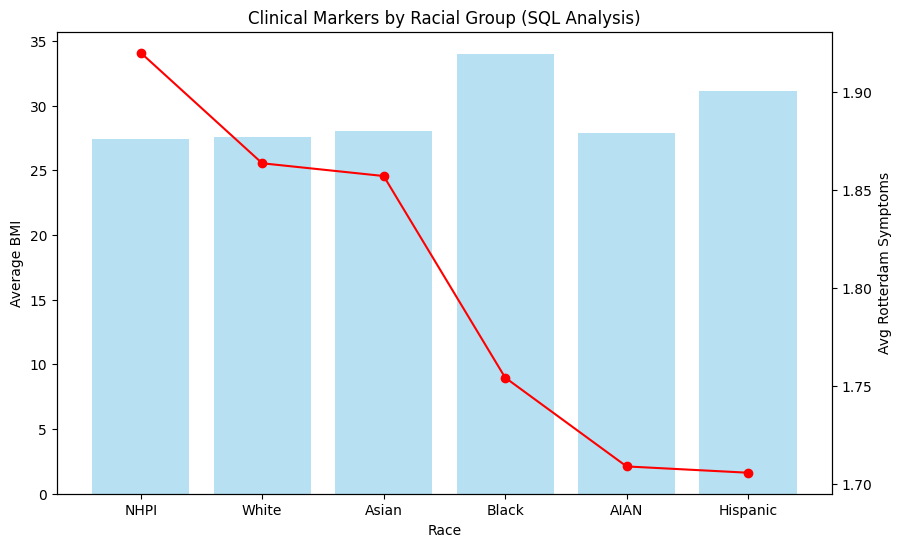

In [12]:
# QUERY TESTING 
conn = sqlite3.connect('pcos_research_data.db') # REOPEN CONNECTION FOR QUERIES 

# AVERAGE BMI + SYMPTOM BY RACIAL GROUP 
query = """
SELECT 
    race, 
    AVG(BMI) as avg_bmi, 
    AVG(rotterdam) as avg_symptoms,
    COUNT(*) as patient_count
FROM pcos_records
GROUP BY race
ORDER BY avg_symptoms DESC;
"""
analysis_df = pd.read_sql_query(query, conn)
print(analysis_df)

# PLOT RESULTS 
fig, ax1 = plt.subplots(figsize=(10,6))

# BMI BAR CHART 
ax1.bar(analysis_df['race'], analysis_df['avg_bmi'], color='skyblue', alpha=0.6, label='Avg BMI')
ax1.set_ylabel('Average BMI')
ax1.set_xlabel('Race')

# SYMPTOM LINE CHAR 
ax2 = ax1.twinx()
ax2.plot(analysis_df['race'], analysis_df['avg_symptoms'], color='red', marker='o', label='Avg Symptoms')
ax2.set_ylabel('Avg Rotterdam Symptoms')

plt.title('Clinical Markers by Racial Group (SQL Analysis)')
plt.show()

       race  symptomatic_patients  missed_diagnoses  miss_rate_percentage
0     White                    29                13                 44.83
1  Hispanic                    32                14                 43.75
2     Black                    34                14                 41.18
3     Asian                    46                17                 36.96
4      AIAN                    32                11                 34.38
5      NHPI                    31                10                 32.26


/tmp/ipykernel_3648108/1363981517.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='race', y='miss_rate_percentage', data=underdiagnosed, palette='magma')


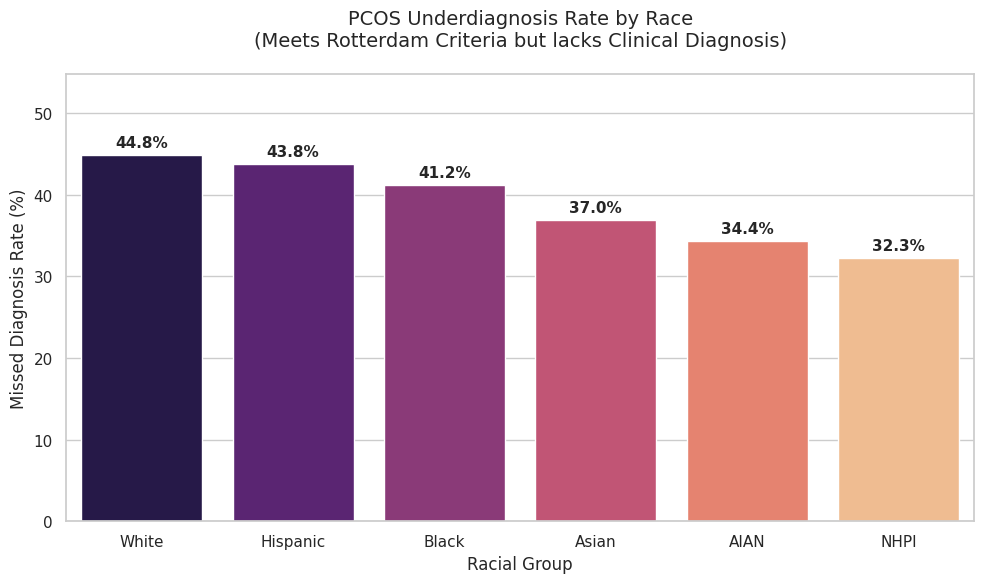

In [13]:
# UNDERDIAGNOSIS GAP - individuals meeting Rotterdam Criteria but NOT diagnosed 
under_diagnosed = """
SELECT 
    race, 
    COUNT(*) AS symptomatic_patients,
    SUM(CASE WHEN diagnosis = 0 THEN 1 ELSE 0 END) AS missed_diagnoses,
    ROUND(AVG(CASE WHEN diagnosis = 0 THEN 1.0 ELSE 0.0 END) * 100, 2) AS miss_rate_percentage
FROM pcos_records
WHERE rotterdam >= 2
GROUP BY race
ORDER BY miss_rate_percentage DESC;
"""

underdiagnosed = pd.read_sql_query(under_diagnosed, conn)
print(underdiagnosed)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# BAR PLOT - SORT BY miss_rate_percentage TO VISUALIZE DISPARITIES 
underdiagnosed = underdiagnosed.sort_values('miss_rate_percentage', ascending=False)
ax = sns.barplot(x='race', y='miss_rate_percentage', data=underdiagnosed, palette='magma')

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('PCOS Underdiagnosis Rate by Race\n(Meets Rotterdam Criteria but lacks Clinical Diagnosis)', fontsize=14, pad=20)
plt.xlabel('Racial Group', fontsize=12)
plt.ylabel('Missed Diagnosis Rate (%)', fontsize=12)
plt.ylim(0, max(underdiagnosed['miss_rate_percentage']) + 10) # Add room for labels
plt.tight_layout()
plt.show()
